# 04 — Side-view geometry: anti-dive & anti-squat

**Concepts (Carroll Smith ch. 5, Milliken ch. 17):**

When you brake, load transfers forward and the nose dives. When you accelerate,
load transfers rearward and the rear squats. The suspension geometry can be
designed to resist some of this pitch through the linkage itself — that's
anti-dive (front) and anti-squat (rear).

The mechanism: each A-arm's pivot axis has a slope when viewed from the side.
If the rear inboard pivot is higher than the front pivot, the axis slopes upward
toward the rear. Extending both arm axes to their intersection gives the
**side-view instant center (SVIC)**. The angle from the contact patch to the
SVIC, compared to a reference angle involving CG height and wheelbase, gives
the anti-dive or anti-squat percentage.

**Targets for a street/track car:**
- Front anti-dive: 15–25% (too much feels harsh over bumps under braking)
- Rear anti-squat: 15–50% (more is tolerable here since acceleration is smoother)
- 0% = all pitch goes through springs (soft, lots of dive/squat)
- 100% = geometry resists all pitch (harsh, suspension won't compress under load transfer)

**Key insight:** anti-dive and anti-squat are controlled by the INCLINATION of
the pivot axes — tilting them in the side view. This is independent of the
front-view geometry (which controls camber, roll center, etc.). You can tune
them somewhat independently, which is one of the beauties of a double-wishbone
suspension.

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt

from suspension.hardpoints import example_frontend_hardpoints
from suspension.kinematics_front import solve_corner, compute_camber, wheel_travel
from suspension.roll_center import compute_roll_geometry_sweep
from suspension.side_view import (
    find_side_view_ic, anti_dive_percent, anti_squat_percent,
    compute_side_view_sweep,
)
from suspension.hardpoint_io import print_summary

print("Imports OK")

Imports OK


## Vehicle parameters

These are estimates for the C3 with driver. We'll refine them once you
get the car on scales. The key numbers for anti-geometry are CG height
and wheelbase — everything else is secondary.

In [2]:
# Vehicle parameters — estimates for a 1972 C3 with driver
vehicle = {
    'cg_height': 0.460,             # ~18 inches, typical for a C3
    'wheelbase': 2.489,             # 98.0 inches (C3 spec)
    'front_weight_fraction': 0.52,  # C3 is slightly nose-heavy with SBC
    'brake_bias_front': 0.60,       # typical street bias, adjustable later
    'is_front': True,
}

hp = example_frontend_hardpoints()
print_summary(hp)

# Static side-view IC
svic = find_side_view_ic(
    hp.upper_front_pivot, hp.upper_rear_pivot, hp.upper_ball_joint,
    hp.lower_front_pivot, hp.lower_rear_pivot, hp.lower_ball_joint,
)

if svic is not None:
    print(f"\n=== Side-view geometry (static) ===")
    print(f"SVIC position (x, z): ({svic[0]*1000:.0f}, {svic[1]*1000:.0f}) mm")
    
    ad = anti_dive_percent(svic, hp.contact_patch, 
                           vehicle['cg_height'], vehicle['wheelbase'],
                           vehicle['front_weight_fraction'],
                           vehicle['brake_bias_front'])
    print(f"Anti-dive: {ad:.1f}%")
    
    # Show the pivot axis slopes
    upper_slope = ((hp.upper_rear_pivot[2] - hp.upper_front_pivot[2]) / 
                   (hp.upper_rear_pivot[0] - hp.upper_front_pivot[0]))
    lower_slope = ((hp.lower_rear_pivot[2] - hp.lower_front_pivot[2]) / 
                   (hp.lower_rear_pivot[0] - hp.lower_front_pivot[0]))
    print(f"\nUpper pivot axis slope (dz/dx): {upper_slope:.4f} ({np.rad2deg(np.arctan(upper_slope)):.2f} deg)")
    print(f"Lower pivot axis slope (dz/dx): {lower_slope:.4f} ({np.rad2deg(np.arctan(lower_slope)):.2f} deg)")
    print(f"\nNote: the placeholder hardpoints have LEVEL pivot axes (slope=0),")
    print(f"so anti-dive is {ad:.1f}%. Real C3 axes have a slight upward slope")
    print(f"toward the rear to generate ~15-20% anti-dive.")
else:
    print("SVIC: parallel pivot axes (no anti-geometry)")

=== Hardpoint summary (mm) ===
  upper_front_pivot          X=   150.0  Y=  -250.0  Z=   500.0
  upper_rear_pivot           X=  -150.0  Y=  -250.0  Z=   500.0
  upper_ball_joint           X=     0.0  Y=  -620.0  Z=   530.0
  lower_front_pivot          X=   180.0  Y=  -200.0  Z=   180.0
  lower_rear_pivot           X=  -180.0  Y=  -200.0  Z=   180.0
  lower_ball_joint           X=     0.0  Y=  -680.0  Z=   160.0
  wheel_center               X=     0.0  Y=  -720.0  Z=   320.0
  contact_patch              X=     0.0  Y=  -720.0  Z=     0.0

  Upper arm length (pivot ctr → BJ): 371.2 mm
  Lower arm length (pivot ctr → BJ): 480.4 mm
  Upright length (BJ → BJ):          374.8 mm
  Arm length ratio (upper/lower):     0.773
SVIC: parallel pivot axes (no anti-geometry)


## Exploring the effect of pivot axis tilt

The placeholder hardpoints have perfectly level pivot axes, so anti-dive is
near zero. Let's see what happens when we tilt them — this is the primary
design lever for anti-dive/squat.

We'll sweep the rear pivot height of the lower arm upward while keeping
everything else fixed, to see how anti-dive changes.

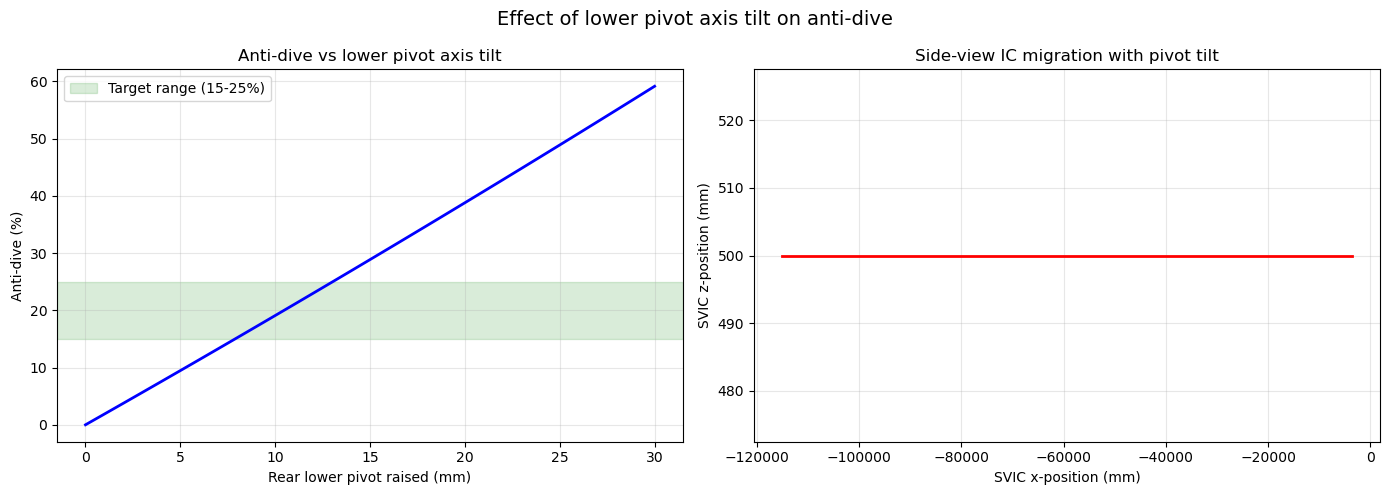


To get ~20% anti-dive:
  Raise rear lower pivot by 10 mm
  Anti-dive: 19.1%


In [3]:
# Parametric study: tilt the lower pivot axis by raising the rear lower pivot
# This simulates angling the lower A-arm axis upward toward the rear
tilt_range_mm = np.linspace(0, 30, 31)  # raise rear lower pivot 0-30mm

anti_dive_results = []
svic_positions = []

hp_base = example_frontend_hardpoints()

for tilt_mm in tilt_range_mm:
    # Copy hardpoints and modify
    hp_mod = example_frontend_hardpoints()
    hp_mod.lower_rear_pivot = hp_base.lower_rear_pivot.copy()
    hp_mod.lower_rear_pivot[2] += tilt_mm / 1000.0  # raise z
    
    svic = find_side_view_ic(
        hp_mod.upper_front_pivot, hp_mod.upper_rear_pivot, hp_mod.upper_ball_joint,
        hp_mod.lower_front_pivot, hp_mod.lower_rear_pivot, hp_mod.lower_ball_joint,
    )
    
    if svic is not None:
        ad = anti_dive_percent(svic, hp_mod.contact_patch,
                               vehicle['cg_height'], vehicle['wheelbase'],
                               vehicle['front_weight_fraction'],
                               vehicle['brake_bias_front'])
        anti_dive_results.append(ad)
        svic_positions.append(svic)
    else:
        anti_dive_results.append(0)
        svic_positions.append([np.nan, np.nan])

anti_dive_results = np.array(anti_dive_results)
svic_positions = np.array(svic_positions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(tilt_range_mm, anti_dive_results, 'b-', linewidth=2)
ax.axhspan(15, 25, alpha=0.15, color='green', label='Target range (15-25%)')
ax.set_xlabel('Rear lower pivot raised (mm)')
ax.set_ylabel('Anti-dive (%)')
ax.set_title('Anti-dive vs lower pivot axis tilt')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(svic_positions[:, 0] * 1000, svic_positions[:, 1] * 1000, 'r-', linewidth=2)
ax.set_xlabel('SVIC x-position (mm)')
ax.set_ylabel('SVIC z-position (mm)')
ax.set_title('Side-view IC migration with pivot tilt')
ax.grid(True, alpha=0.3)

fig.suptitle('Effect of lower pivot axis tilt on anti-dive', fontsize=14)
fig.tight_layout()
plt.show()

# Print the tilt that gives ~20% anti-dive
target_idx = np.argmin(np.abs(anti_dive_results - 20))
print(f"\nTo get ~20% anti-dive:")
print(f"  Raise rear lower pivot by {tilt_range_mm[target_idx]:.0f} mm")
print(f"  Anti-dive: {anti_dive_results[target_idx]:.1f}%")

## Side-view construction diagram

This shows the pivot axes in the side view and how they converge at the SVIC.
Compare this to the front-view IC construction from notebook 03 — same
concept, different plane.

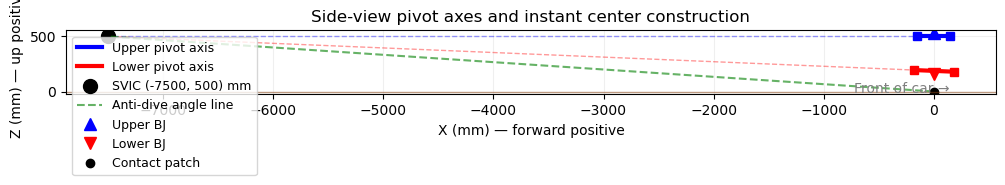

Anti-dive with 15mm rear lower pivot raise: 28.9%


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

hp = example_frontend_hardpoints()
# Use a modified version with some anti-dive for a more interesting diagram
hp.lower_rear_pivot[2] += 0.015  # raise 15mm for ~10% anti-dive

svic = find_side_view_ic(
    hp.upper_front_pivot, hp.upper_rear_pivot, hp.upper_ball_joint,
    hp.lower_front_pivot, hp.lower_rear_pivot, hp.lower_ball_joint,
)

# Draw pivot axes
ax.plot([hp.upper_front_pivot[0]*1000, hp.upper_rear_pivot[0]*1000],
        [hp.upper_front_pivot[2]*1000, hp.upper_rear_pivot[2]*1000],
        'b-', linewidth=3, label='Upper pivot axis')
ax.plot([hp.lower_front_pivot[0]*1000, hp.lower_rear_pivot[0]*1000],
        [hp.lower_front_pivot[2]*1000, hp.lower_rear_pivot[2]*1000],
        'r-', linewidth=3, label='Lower pivot axis')

# Extend to SVIC
if svic is not None:
    ax.plot([hp.upper_front_pivot[0]*1000, svic[0]*1000],
            [hp.upper_front_pivot[2]*1000, svic[1]*1000],
            'b--', alpha=0.4, linewidth=1)
    ax.plot([hp.lower_front_pivot[0]*1000, svic[0]*1000],
            [hp.lower_front_pivot[2]*1000, svic[1]*1000],
            'r--', alpha=0.4, linewidth=1)
    ax.plot(svic[0]*1000, svic[1]*1000, 'ko', markersize=10,
            label=f'SVIC ({svic[0]*1000:.0f}, {svic[1]*1000:.0f}) mm')

    # Line from contact patch to SVIC (the anti-dive angle)
    ax.plot([hp.contact_patch[0]*1000, svic[0]*1000],
            [hp.contact_patch[2]*1000, svic[1]*1000],
            'g--', linewidth=1.5, alpha=0.6, label='Anti-dive angle line')

# Ball joints
ax.plot(hp.upper_ball_joint[0]*1000, hp.upper_ball_joint[2]*1000,
        'b^', markersize=8, label='Upper BJ')
ax.plot(hp.lower_ball_joint[0]*1000, hp.lower_ball_joint[2]*1000,
        'rv', markersize=8, label='Lower BJ')

# Pivot points
for p, c in [(hp.upper_front_pivot, 'b'), (hp.upper_rear_pivot, 'b'),
             (hp.lower_front_pivot, 'r'), (hp.lower_rear_pivot, 'r')]:
    ax.plot(p[0]*1000, p[2]*1000, c+'s', markersize=6)

# Contact patch
ax.plot(hp.contact_patch[0]*1000, hp.contact_patch[2]*1000,
        'ko', markersize=6, label='Contact patch')

# Ground
ax.axhline(0, color='saddlebrown', linewidth=1, alpha=0.5)

# Labels
ax.annotate('Front of car →', xy=(0.95, 0.02), xycoords='axes fraction',
            fontsize=10, ha='right', color='gray')

ax.set_xlabel('X (mm) — forward positive')
ax.set_ylabel('Z (mm) — up positive')
ax.set_title('Side-view pivot axes and instant center construction')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
plt.show()

if svic is not None:
    ad = anti_dive_percent(svic, hp.contact_patch,
                           vehicle['cg_height'], vehicle['wheelbase'],
                           vehicle['front_weight_fraction'],
                           vehicle['brake_bias_front'])
    print(f"Anti-dive with 15mm rear lower pivot raise: {ad:.1f}%")

## What this means for your C3

The placeholder hardpoints have level pivot axes, giving ~0% anti-dive. The
stock C3 has a small amount of anti-dive built in — probably 10-15%.

When you get to designing the new arms, you have a clean lever to pull:
**tilt the pivot axes in the side view.** Raising the rear inboard pivots
(or lowering the front ones) increases anti-dive. The parametric study above
shows how much tilt you need for your target.

For the rear (which we'll model next), the same concept applies but it's
called anti-squat. The rear pivot axes slope in the opposite sense — typically
the front lower pivot is higher than the rear, so the axis slopes downward
toward the rear, generating anti-squat under acceleration.

**Next up:** Notebook 05 will be the parametric trade study where you can
slide hardpoints around and see camber, RC, IC, and anti-geometry all
respond together. That's where the design iteration really starts.